In [1]:
%pip install pandas matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

df = pd.read_csv("snatch_data.csv", on_bad_lines='skip')

print(df)

    Rank                  Name Nation  Born  Bodyweight Group  Total
0      1                 Delia    ITA  2005       52.99     A   85.0
1      2  Monasterio Urbitarte    ESP  2006       52.55     A   84.0
2      3           Stratoudaki    GRE  2008       52.68     A   82.0
3      4                 Sipos    ROU  2009       52.79     A   81.0
4      5           Katsianiova    AIN  2007       52.64     A   75.0
5      6               Popescu    MDA  2006       52.14     A   70.0
6      7            Starostina    AIN  2006       52.07     A   70.0
7      8               Roussel    FRA  2006       52.30     A   70.0
8      9      Camilleri Lagana    MLT  2008       51.93     A   69.0
9     10            Cruikshunk    GBR  2007       52.19     A   68.0
10    11               Kozlova    CZE  2005       52.07     A   65.0
11    12               Scherer    GER  2005       52.62     A   65.0
12     1             Grigoryan    ARM  2005       56.90     A   91.0
13     2                Berchi    

In [3]:
df = df.dropna()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rank        26 non-null     int64  
 1   Name        26 non-null     str    
 2   Nation      26 non-null     str    
 3   Born        26 non-null     int64  
 4   Bodyweight  26 non-null     float64
 5   Group       26 non-null     str    
 6   Total       26 non-null     float64
dtypes: float64(2), int64(2), str(3)
memory usage: 1.6 KB


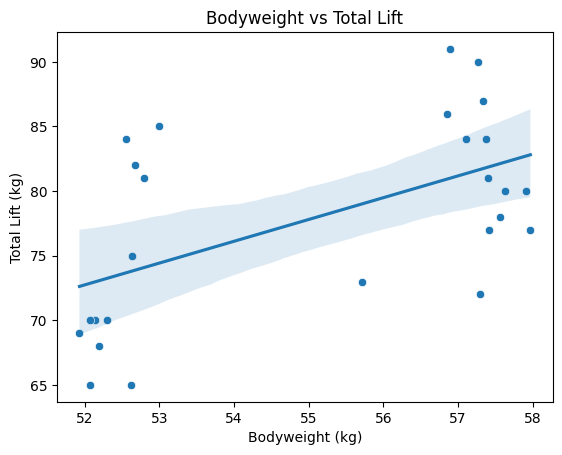

In [ ]:
import matplotlib.pyplot as plt   #import libraries that help us create the plots we want
import seaborn as sns

plt.figure()
sns.scatterplot(x='Bodyweight', y='Total', data=df)

# Add trendline for checking if there is any pattern between the two variables
sns.regplot(x='Bodyweight', y='Total', data=df, scatter=False)

plt.xlabel("Bodyweight (kg)")
plt.ylabel("Total Lift (kg)")
plt.title("Bodyweight vs Total Lift")

plt.show()

In [ ]:
correlation = df['Bodyweight'].corr(df['Total'])
print("Correlation:", correlation)   #figuring out if there is any strong relationship between an athlete's body weight and total weight lifted

Correlation: 0.5576372584635582


In [12]:
df['Strength_ratio'] = df['Total'] / df['Bodyweight']

df.sort_values(by='Strength_ratio', ascending=False).head(10)

,Rank,Name,Nation,Born,Bodyweight,Group,Total,Strength_ratio,Strength_to_Weight_ratio
0,1,Delia,ITA,2005,52.99,A,85.0,1.604076,1.604076
12,1,Grigoryan,ARM,2005,56.90,A,91.0,1.599297,1.599297
1,2,Monasterio Urbitarte,ESP,2006,52.55,A,84.0,1.598478,1.598478
13,2,Berchi,ROU,2005,57.27,A,90.0,1.571503,1.571503
2,3,Stratoudaki,GRE,2008,52.68,A,82.0,1.556568,1.556568
3,4,Sipos,ROU,2009,52.79,A,81.0,1.534382,1.534382
14,3,Ollala Munoz,ESP,2005,57.33,A,87.0,1.517530,1.517530
15,4,Cojocura,MDA,2009,56.85,A,86.0,1.512753,1.512753
17,6,Pratt,GBR,2007,57.11,A,84.0,1.470846,1.470846
16,5,Honcharova,UKR,2008,57.37,A,84.0,1.464180,1.464180


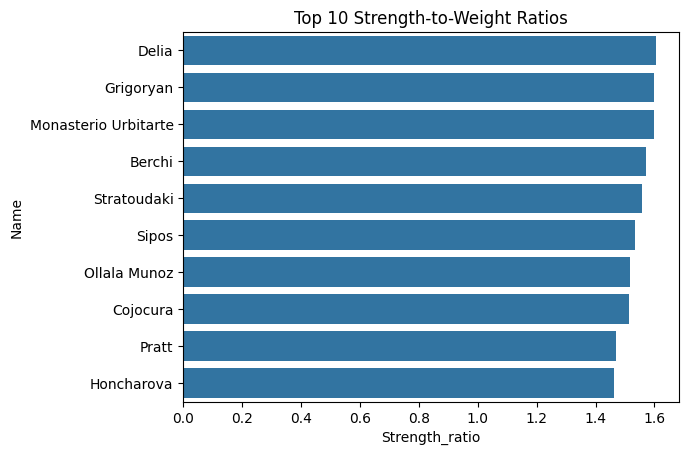

In [13]:
top = df.sort_values(by='Strength_ratio', ascending=False).head(10)

plt.figure()
sns.barplot(x='Strength_ratio', y='Name', data=top)

plt.title("Top 10 Strength-to-Weight Ratios")

plt.show()

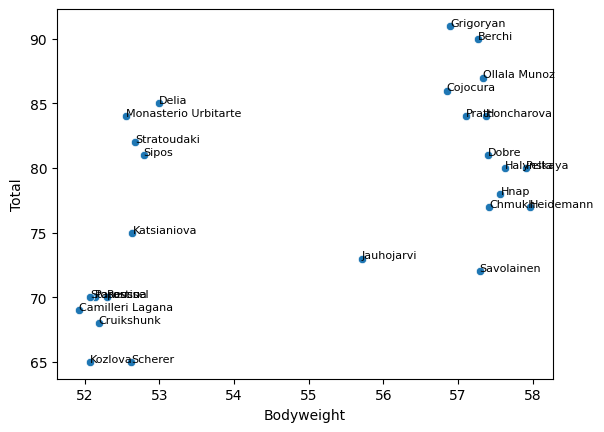

In [14]:
plt.figure()

sns.scatterplot(x='Bodyweight', y='Total', data=df)

for i in range(len(df)):
    plt.text(df['Bodyweight'][i], df['Total'][i], df['Name'][i], fontsize=8)

plt.show()